> **Recorded AWS execution — 20260922-004148.** This notebook preserves the original code and scientific outputs. It is an evidence snapshot, not a claim that a data-free clone can rerun the private workspace. Start with [the portfolio overview](00_portfolio_overview.ipynb); see [reproduction instructions](../docs/REPRODUCIBILITY.md) and [current status](../docs/STATUS.md).


# 29 · Competing-parent division model

## Objective and evidence

The exact error audit found four missed divisions with parent and daughter support but no fork. Their missing daughter links were already assigned to other parents. The earlier add-only retention rule could not correct that case. This experiment **generates new division alternatives and explicitly compares a division with two independent continuations**.

The scored public reference remains frozen: official snapshot **0.947**, leader snapshot **0.974** (September 21, 17:51 UTC). These are not the five-movie development scores. No Kaggle action occurs.

This is a new small graph-feature model, not a claimed HOCT, Trackastra, or winning-method reproduction. The higher-order literature motivates evaluating competing lineage hypotheses rather than assuming that the strongest independent edge is sufficient.

In [1]:
from pathlib import Path
import json,warnings
import plotly.graph_objects as go
from IPython.display import Image,display
OUT=Path('/home/sagemaker-user/biohub-cell-tracking-during-development/outputs/competitive_gap_closure/competing_parent_events')
def show(fig,height=580):
    fig.update_layout(width=1040,height=height,margin=dict(l=100,r=55,t=100,b=110))
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore',category=DeprecationWarning)
        png=fig.to_image(format='png',width=1040,height=height,scale=1)
    display(Image(data=png))

r=json.loads((OUT/'result.json').read_text())
assert r['status']=='complete' and r['approved_for_submission'] is False
contract=json.loads((OUT/'experiment_contract.json').read_text())
coverage=json.loads((OUT/'coverage.json').read_text())
print('Cohort:',', '.join(r['measured_movies']))
print('Frozen control:',format(r['baseline']['score'],'.9f'))
print('Fixed feature count:',len(contract['features']))
print('New fits:',r['new_fits'],'Reused fits:',r['reused_fits'])
print('Decision:',r['decision'])


Cohort: 44b6_12dfb391, 6bba_062c8d37, 44b6_267148e4, 6bba_07e24132, 44b6_2a2eff9f
Frozen control: 0.933045673
Fixed feature count: 29
New fits: 2 Reused fits: 0
Decision: reject_fixed_competing_parent_event_model


## Hypotheses are generated before annotations

For each unary parent, examine up to four alternate next-frame detections within 15 µm. An alternative may already have a different unary parent. A transaction removes that competing incoming edge and adds the second daughter to the proposed dividing parent. Existing division edges are protected; nodes and coordinates remain unchanged.

Features use relative geometry, parent/daughter motion, trajectory support, and the competing incoming association. Movie IDs, embryo IDs, absolute time, GT coordinates, and annotation-derived identities are excluded. All five feature arrays are saved before opening annotations. Radius and feature design are fixed for this screen, not tuned on its result.

The following **label-assisted coverage** check is not a model score: it asks whether the generated alternatives include an annotated event. Unassessable proposals are ignored during learning, not made negative.

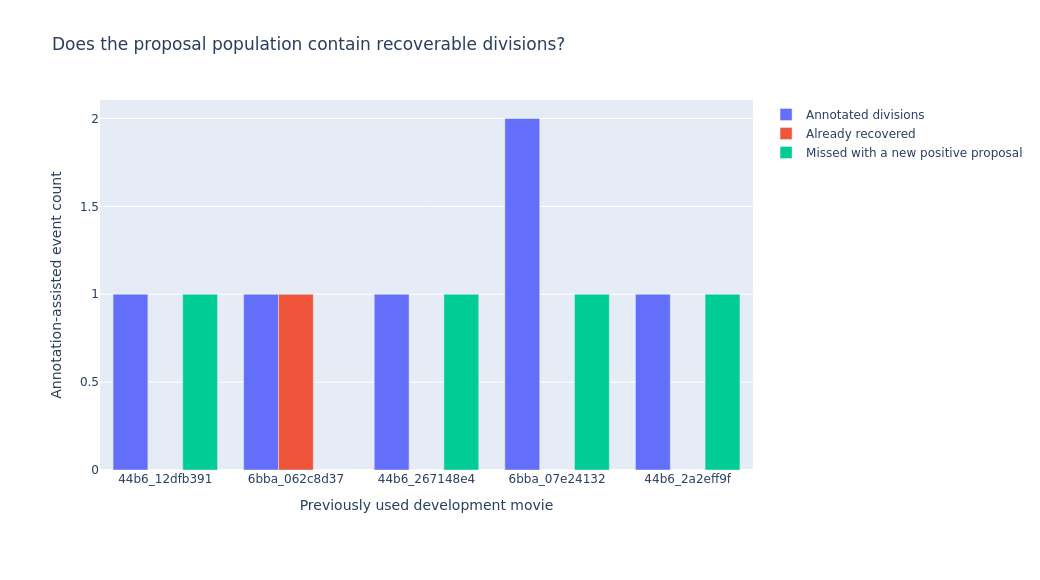

In [2]:
labels=[c['stem'] for c in coverage]
fig=go.Figure()
fig.add_bar(name='Annotated divisions',x=labels,y=[c['annotated_divisions'] for c in coverage])
fig.add_bar(name='Already recovered',x=labels,y=[c['baseline_recovered'] for c in coverage])
fig.add_bar(name='Missed with a new positive proposal',x=labels,y=[c['missed_divisions_with_positive_new_proposal'] for c in coverage])
fig.update_layout(title='Does the proposal population contain recoverable divisions?',barmode='group',xaxis_title='Previously used development movie',yaxis_title='Annotation-assisted event count')
show(fig)


## Two embryo-disjoint learning tasks

Train on embryo 44b6 and predict embryo 6bba; then reverse. Fit scaling, model coefficients, and the selection threshold on the training embryo only. Positive proposals are weighted by distinct division event so duplicate temporal variants do not count as independent events. The regularized logistic score is **not a calibrated probability**. The threshold exceeds the largest training-negative score and is at least 0.5.

At least two distinct annotated positive division events and twenty known negative proposals are required in each training embryo. Otherwise the run stops before fitting. There are at most two fits, no parameter sweep, and at most 32 accepted nonconflicting events per movie. This budget is a safety limit, not a biological assumption.

All held-out graphs are frozen before candidate scoring. The original metric is unchanged. Proposal-level training labels are conservative proxies using exact baseline division-window matches and known lineage components; final acceptance uses full graph evaluation.

Actual score delta: 0.0


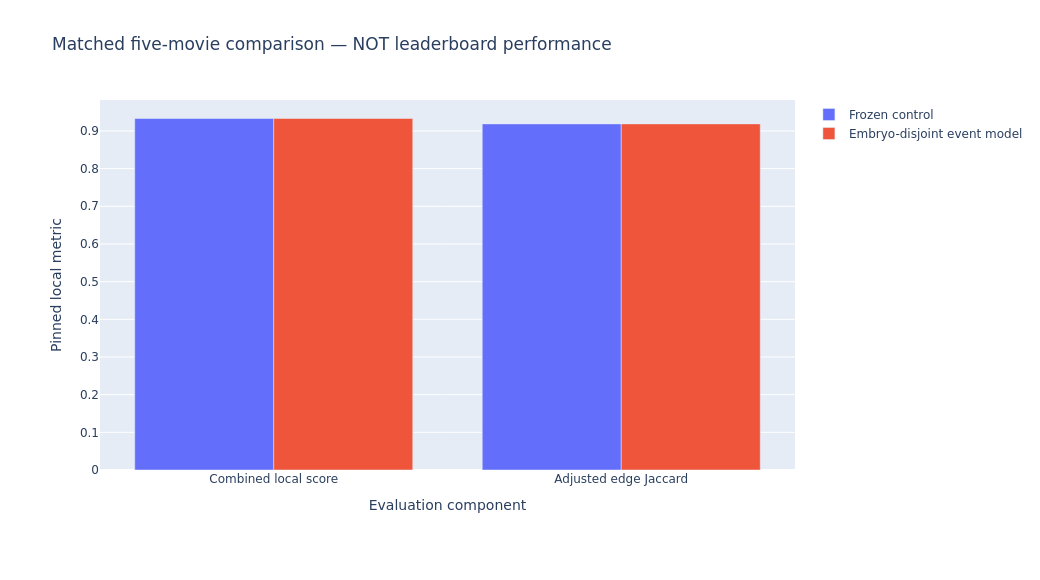

In [3]:
fig=go.Figure()
fig.add_bar(name='Frozen control',x=['Combined local score','Adjusted edge Jaccard'],y=[r['baseline']['score'],r['baseline']['adj_edge_jaccard']])
if r.get('candidate') is not None:
    fig.add_bar(name='Embryo-disjoint event model',x=['Combined local score','Adjusted edge Jaccard'],y=[r['candidate']['score'],r['candidate']['adj_edge_jaccard']])
    print('Actual score delta:',r['score_delta'])
else:
    print('No model comparison: training-readiness gate was not met.')
fig.update_layout(title='Matched five-movie comparison — NOT leaderboard performance',barmode='group',yaxis_title='Pinned local metric',xaxis_title='Evaluation component')
show(fig)


## What changed in the tracking graph?

New divisions can improve division recall but also damage correct incoming associations. Both effects are measured; a rise in probability score alone is not an improvement. The original nodes, coordinates, and reference files remain unchanged. All new graphs are experimental and kept out of the competition submission path.

Accepted new forks: 108
Reassigned children: 47
Embryo 44b6 local score delta 0.0
Embryo 6bba local score delta 0.0


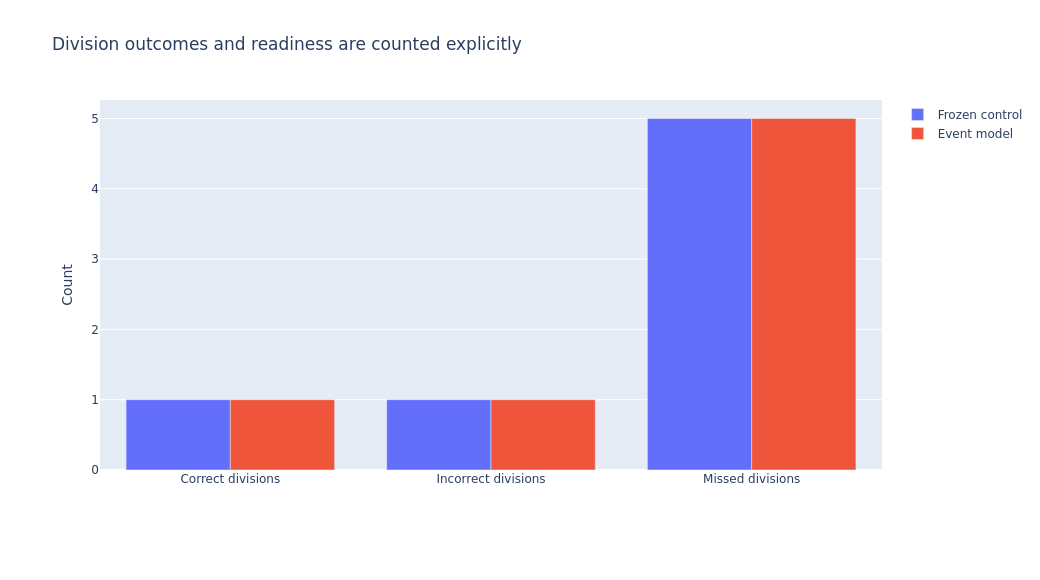

In [4]:
fig=go.Figure()
if r.get('candidate') is not None:
    keys=['division_tp','division_fp','division_fn']
    names=['Correct divisions','Incorrect divisions','Missed divisions']
    fig.add_bar(name='Frozen control',x=names,y=[r['baseline'][k] for k in keys])
    fig.add_bar(name='Event model',x=names,y=[r['candidate'][k] for k in keys])
    print('Accepted new forks:',r['accepted_new_forks'])
    print('Reassigned children:',r['reassigned_children'])
    for row in r['embryos']:print('Embryo',row['embryo'],'local score delta',row['delta'])
else:
    readiness=json.loads((OUT/'training_readiness.json').read_text())
    fig.add_bar(name='Distinct training divisions',x=[x['heldout_embryo'] for x in readiness],y=[x['distinct_training_divisions'] for x in readiness])
fig.update_layout(title='Division outcomes and readiness are counted explicitly',barmode='group',yaxis_title='Count')
show(fig)


## Decision and limitations

Promotion requires local score gain ≥0.002, adjusted-edge loss ≤0.0005, no embryo-level score loss, no loss of division true positives, and no additional division false positives. Otherwise reject the fixed model. No automatic submission or follow-on run occurs.

**Only six annotated division events exist in these two repeatedly examined development embryos.** Cross-embryo fitting prevents direct training-row leakage but does not undo prior researcher exposure or establish pretrained-checkpoint independence. A positive screen earns independent confirmation, not a claim that the leader was beaten.

Research context: Trackastra (Gallusser and Weigert, 2024), Higher-Order Cell Tracking Transformer (Bragantini, Theodoro and Royer, July 2026). Their full architectures and published benchmark gains are not reproduced or claimed here. Pin: RoyerLab evaluator commit 075fc5f5a52d11077f9dc2b074644618f26939e2. No new pretrained weights are used.

In [5]:
print('Decision:',r['decision'])
print('Approved for submission:',r['approved_for_submission'])
print('Preserved reference; no downloads, GPU inference or Kaggle actions.')
print('BIOHUB_COMPETING_PARENT_NOTEBOOK_COMPLETE')

Decision: reject_fixed_competing_parent_event_model
Approved for submission: False
Preserved reference; no downloads, GPU inference or Kaggle actions.
BIOHUB_COMPETING_PARENT_NOTEBOOK_COMPLETE
